In [3]:
import boto3
import glob
import os, ssl, certifi, requests, json
from langgraph.graph import StateGraph, START, END
from langchain_community.vectorstores import Chroma
from IPython.display import Image, display
from langchain_core.documents import Document
from typing import List, Dict, TypedDict
from langchain_aws import BedrockEmbeddings, ChatBedrock
from langchain_classic.retrievers.ensemble import EnsembleRetriever
from langchain_community.retrievers.bm25 import BM25Retriever
from pydantic import BaseModel, Field
from langchain_core.globals import set_llm_cache
from langchain_community.cache import SQLiteCache
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate
from langsmith import traceable, Client
from botocore.config import Config

In [4]:
# CONSTANTS
os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGCHAIN_TRACING"] = "false"
os.environ["LANGCHAIN_API_KEY"] = "none"
# Your vectorstore defined path
LOCAL_VECTORSTORE_PATH = '/Users/sridhartondapi/Documents/python_self_corr_rag_prj_v1/data/chroma_db'

# Your inference model id
MODEL_ID = "us.anthropic.claude-sonnet-4-20250514-v1:0" 

# Your embedding model id
EMBEDDING_MODEL_ID = "amazon.titan-embed-text-v2:0"

# Chroma Collection name 

collection_name = "pdf_knowledge_base"

# Model params

CONFIDENCE_THRESHOLD = 0.80

bedrock_config = Config(
    connect_timeout=60,          # seconds to establish connection
    read_timeout=300,            # ← most important: 5 minutes — start here
    retries={'max_attempts': 3}
)


# Your AWS Boto3 connection details
bedrock = boto3.client(service_name="bedrock-runtime", 
                        region_name='us-east-1',
                        config = bedrock_config)

In [5]:
class Navigationalresponse(BaseModel):
    question: str = Field()
    answer: str = Field()

In [6]:

PROMPT_TEMPLATE = """
=== RELEVANT DOCUMENTS — READ THESE FIRST (THIS IS THE ONLY EVIDENCE) ===
{context}

=== INSTRUCTIONS (follow strictly) ===
**Identify the document and filters to use based strictly on the provided context chunks above.**

**Instructions**
- For questions like "How to check [something]?", "How many [something] by [something]?", "How to find [entity_1] by [entity_2] and [entity_3] [value]", or "Show [something]":
- Extract all main entities explicitly mentioned or implied in the question.
- To map entities to document-specific columns: Check the synonym reference document 'Business attribute synonym reference.pdf' first.
- **COMPREHENSIVE MULTI-DOCUMENT SEARCH RULE:** You must examine every single chunk in the context. If the entities or filters are present in multiple documents (e.g., Submission Report, Test Day Report, and TDTK Report), you are STRICTLY REQUIRED to list ALL of them in a numbered list. Do not stop searching after finding the first relevant document.
- For date-based queries (e.g., "test date", "started testing on", "testing on"), you must include all documents with date-related filters: "Test Start Date" in Student Submission Report, and "Actual Start Date" in End to End Dashboard, TDTK Readiness, and Exam schedule Reports.

- **Special case for response formatting:**
- Generalize document names in navigation instructions:
  - "SAT & PSAT Student Submission Report" -> "Student Submission Report of your specific year"
  - "SAT School Day & PSAT Test Day Report" -> "Test Day report of your specific year"
  - "SAT School Day & PSAT End to End Dashboard" -> "End to End Dashboard of your specific year"
  - "PSAT TDTK Readiness" -> "TDTK Readiness report of your specific year"
  - "SAT School Day & PSAT Exam schedule Report" -> "Exam schedule report of your specific year"
- Keep original names in `source()` references (e.g., `source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)`).

- **Response format (Strict Enforcement):**
- Every navigation line MUST start with a capital "**P**" (e.g., "Please navigate to...").
- **If multiple documents contain the entities:** You must use a numbered list.
  1. Please navigate to the [generalized_name_1] and filter [entities] accordingly source([filename_1].pdf)
  2. Please navigate to the [generalized_name_2] and filter [entities] accordingly source([filename_2].pdf)
- **If only one document contains the entities:** "Please navigate to the [generalized_name] and filter [entities] accordingly source([filename].pdf)"
- **If no document contains all entities:** "No relevant document found for [entities]. source(none)"

- Strictly output only the specified response format without any introductory phrases like "Based on the context" or "Here is the answer."

**Examples**
- Question: "how to check for students tested on 10/8/2024" 
  Answer: 
  1. Please navigate to the Student Submission Report of your specific year and filter Test Start Date as '2024-10-08' accordingly source(SAT & PSAT Student Submission Report_final_wo_syn.pdf)
  2. Please navigate to the Test Day report of your specific year and filter Test Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT Test Day Report_final.pdf)
  3. Please navigate to the End to End Dashboard of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT End to End Dashboard_final.pdf)
  4. Please navigate to the TDTK Readiness report of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(PSAT TDTK Readiness_final.pdf)
  5. Please navigate to the Exam schedule report of your specific year and filter Actual Start Date as '2024-10-08' accordingly source(SAT School Day & PSAT Exam schedule Report_final.pdf)

Question: {question}
Answer:
"""

In [7]:
def bedrock_connection():
    return ChatBedrock(
        model_id = MODEL_ID,
        client = bedrock,
        model_kwargs = {
            # PRE-LLM GUARDRAIL #1 
            #"guardrailIdentifier": "rg-your-guardrail-id",  # Add this
            "top_p": 0.1,
            "temperature": 0.1,
            "max_tokens": 512
        }
    )

In [8]:
try:
    llm = bedrock_connection()
except Exception as e:
    print (f"Unable to Connect to the Bedrock: {str(e)}")

In [9]:
class AgentState(TypedDict):
    question: str
    sub_queries: List[str]
    answer: str
    retrieved_documents: List[Document]
    retrieved_sources: List[Document]
    iteration: int
    confidence: float

In [10]:
custom_prompt = PromptTemplate(
    input_variables=["question","context"],
    template = PROMPT_TEMPLATE
)

In [12]:
class RetrievalContext:
    def __init__(self, vectorstore, BM25Retriever):
        self.vectorstore = vectorstore
        self.BM25Retriever = BM25Retriever

    def hybrid_docs(self, query:str, iteration: int = 0, semantic_weight: float = 0.3):
        adaptive_k = 12 +( iteration * 8)
        adaptive_fetch = 40 + (iteration * 15)

        semantic = self.vectorstore.as_retriever(
            search_type = "mmr",
            search_kwargs = {
                "k": adaptive_k,
                "fetch_k": adaptive_fetch,
                "lambda_mult": 0.6
            }
        )

        self.BM25Retriever.k = adaptive_k

        ensemble = EnsembleRetriever(
            retrievers=[semantic,self.BM25Retriever],
            weights=[semantic_weight, 1 - semantic_weight]
        )

        docs = ensemble.invoke(query)

        return docs

In [13]:
def decompose_query(state:AgentState) -> AgentState:
    question = state['question']

    prompt = f"""Break this question into 1-4 simple quereies for a document system.
    Return ONLY a JSON list of strings.
    Question: {question}"""

    response = llm.invoke(prompt).content.strip()
    try:
        sub_queries = json.loads(response)
    except Exception as e:
        sub_queries = [question]

    return {**state, "sub_queries": sub_queries}

In [14]:
embeddings = BedrockEmbeddings(
    client = bedrock,
    model_id = EMBEDDING_MODEL_ID
)

vectorstore = Chroma(
    persist_directory=LOCAL_VECTORSTORE_PATH,
    collection_name=collection_name,
    embedding_function=embeddings
)

data = vectorstore.get()

text = data['documents']
metadatas = data['metadatas']

bm25_retriever = BM25Retriever.from_texts(
    texts = text,
    metadatas = metadatas
)

retrieval_ctx = RetrievalContext(vectorstore, bm25_retriever)

/var/folders/n2/4kct0prx0xs8h1gf307cx_r00000gn/T/ipykernel_1456/41313540.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [15]:
def bedrock_cohere_rerank(question: str, hybrid_docs: list):
    doc_texts = [doc.page_content for doc in hybrid_docs]
    payload = {
        "query": question,
        "documents": doc_texts,
        "top_n": 20,
        "api_version": 2
    }

    response = bedrock.invoke_model(
        modelId = "cohere.rerank-v3-5:0",
        contentType = "application/json",
        accept = "application/json",
        body = json.dumps(payload).encode("utf-8")
    )

    results = json.loads(response['body'].read().decode("utf-8"))

    reranked_docs = [hybrid_docs[result['index']] for result in results['results']]

    return reranked_docs

In [ ]:
def retrieval_of_the_documents(state:AgentState) -> AgentState:
    question = state['question']
    sub_queries = state.get('sub_queries', [question])
    current_iter = state.get('iteration', 0.0)
    all_collected_docs = []

    for query in sub_queries:
        hybrid_docs = retrieval_ctx.hybrid_docs(query, iteration = current_iter)

        reranked = bedrock_cohere_rerank(question=query, hybrid_docs=hybrid_docs)
        all_collected_docs.extend(reranked)

        unique_docs = {doc.page_content: doc for doc in all_collected_docs}.values()

        state['retrieved_documents'] = list(unique_docs)
        state['retrieved_sources'] = [doc.metadata.get("source","unknown") for doc in unique_docs]

        return {**state}

In [17]:
def generate_answer(state:AgentState)->AgentState:
    question = state['question']
    retrieved_docs = state['retrieved_documents']

    try:

        context_text = "\n\n".join([doc.page_content for doc in retrieved_docs])
        if not context_text.strip():
            print ("DEBUG: Context is EMPTY! Check Vectorstore retrieval")
        
        initial_prompt = custom_prompt.format(
            question = question,
            context = context_text
        )

        initial_answer = llm.invoke(initial_prompt).content.strip()

        # SOURCE GUARDRAIL #2 (ADD THESE 4 LINES)
        
        if 'source(' not in initial_answer or '.pdf)' not in initial_answer:
            print("BLOCKED: Missing source citation")
            state['answer'] = "ERROR: Missing source(filename.pdf)"
            state['confidence'] = "0.0"
            return {**state}
        
        confidence_prompt = f"""
                        You are an evaluator. Compare the Answer against the Context for the given Question.
                        Score the support on a scale of 0.0 to 1.0.

                        Scoring rules:
                        1.0 = fully supported
                        0.7 = mostly supported
                        0.5 = partially supported
                        0.2 = weak support
                        0.0 = not supported

                        Question: {question}
                        Answer: {initial_answer}
                        Context: {context_text}

                        CRITICAL: Return ONLY the float number. Do not include any words, explanations, or punctuation.
                        Example Output: 0.7
                        """
        initial_answer_confidence_score = llm.invoke(confidence_prompt).content.strip()
        state['confidence'] = initial_answer_confidence_score
        print (f"The initial answer is: {initial_answer_confidence_score}")

        state['answer'] = initial_answer

    except Exception as e:
        state['confidence'] = 0.0
        state['answer'] = "unable to get the proper answer."

    return {**state}

In [18]:
def self_correct(state:AgentState)->AgentState:
    confidence = float(state.get('confidence', 0.0))
    curr_iter = state.get('iteration', 0)

    if confidence >= CONFIDENCE_THRESHOLD:
        return {**state}
    
    original_question = state['question']
    original_answer = state['answer']

    new_docs_text = "\n\n".join([docs.page_content for docs in state['retrieved_documents']])
    correction_prompt = f"""
        You are reviewing an AI's answer based on the provided context.

        If the answer is fully correct and follows the required format, respond ONLY with "ACCEPT".

        Otherwise, provide a corrected version that follows these EXACT formatting rules:

        1. Each source document must produce a separate numbered answer.
        2. Start each answer with "Please navigate to..."
        3. Preserve the exact source filenames from the context. Do NOT replace them with placeholders like "Document 1".
        4. Do NOT modify or invent source names.
        5. Number the answers like:
        1. ...
        2. ...
        6. Do not include explanations or introductory text.

        Question: {original_question}
        Answer: {original_answer}
        Context: {new_docs_text}

        Corrected Answer:
        """
    
    try:
        correction_answer = llm.invoke(correction_prompt.format(
            question = original_question,
            answer = original_answer,
            context = new_docs_text
        )
        ).content.strip()

        if "ACCEPT" not in correction_answer.upper():
            state['answer'] = correction_answer
    except Exception as e:
        print (f"self correction call to LLM failed: {str(e)}")

    state['iteration'] = curr_iter + 1
    return {**state}

In [19]:

# Retry guardrail # 3 (Quality + reliability)
def should_continue(state:AgentState):
    confidence = float(state.get('confidence', 0.0))
    current_iteration = state.get('iteration', 0)

    if confidence>=CONFIDENCE_THRESHOLD or current_iteration>=3:
        print (f"Low confidence ({confidence}). REtrying retrieval... (Iteration {current_iteration})")
        return END
    
    return "retrieval_of_the_documents"

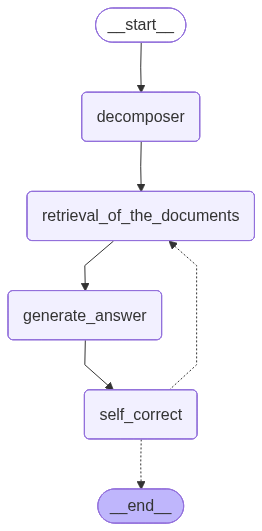

In [20]:
workflow = StateGraph(AgentState)
workflow.add_node("decomposer", decompose_query)
workflow.add_node("retrieval_of_the_documents", retrieval_of_the_documents)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("self_correct", self_correct)

workflow.add_edge(START, "decomposer")
workflow.add_edge("decomposer","retrieval_of_the_documents")
workflow.add_edge("retrieval_of_the_documents","generate_answer")
workflow.add_edge("generate_answer", "self_correct")

workflow.add_conditional_edges(
    "self_correct", should_continue,
    {
        "retrieval_of_the_documents": "retrieval_of_the_documents",
        END: END
    }
)

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))


In [21]:
result = app.invoke({
    "question": "show me students from texas state for event as SAT School Day Fall 2024 Primary and status as Medium risk",
    "answer":"",
    "retrieved_documents": [],
    "retrieved_sources":[],
    "iteration": 0,
    "confidence":0.0
})

result['answer'] = Navigationalresponse(
    question = result['question'],
    answer = result['answer']
).model_dump()

print (f"result is: {result['answer']}")
print (f"iteration is: {result['iteration']}")


The initial answer is: 0.7
The initial answer is: 0.7
The initial answer is: 0.7
Low confidence (0.7). REtrying retrieval... (Iteration 3)
result is: {'question': 'show me students from texas state for event as SAT School Day Fall 2024 Primary and status as Medium risk', 'answer': "Please navigate to the TDTK Readiness report of your specific year and filter State as 'Texas', Event Name as 'SAT School Day Fall 2024 Primary', and Status as 'Medium Risk' accordingly source(SAT School Day/PSAT TDTK Readiness-final.pdf)"}
iteration is: 3
